### **TAYLOR SWIFT**
---
##### Trabajo practico I - Procesamiento del lenguaje natural - ITBA
##### *Análisis exploratorio de datos*
---
Miembros del grupo:
* Magdalena Eppens - 62450
* Sofía Hanna Feilbogen - 61889
* Sofía Gonzalez del Solar - 62292
* Nicole Reiman - 62407


### 1. Librerias

In [ ]:
import pandas as pd
import re
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import nltk
from nltk import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
from textblob import TextBlob
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2. Armado del dataset

In [ ]:
folder_path = '/content/drive/MyDrive/TP NLP/Bases/'
#folder_path='/content/drive/MyDrive/2024/2024 1C/PLN/TP NLP/Bases de datos'
albums = [
    "01-taylor_swift",
    "02-fearless_taylors_version",
    "03-speak_now_deluxe_package",
    "04-red_deluxe_edition",
    "05-1989_deluxe",
    "06-reputation",
    "07-lover",
    "08-folklore_deluxe_version",
    "09-evermore_deluxe_version"
]

dataframes = []

for album in albums:
    #file_path = f"{folder_path}/{album}.csv"
    file_path = f"{album}.csv"
    df = pd.read_csv(file_path)
    df['Album'] = album
    dataframes.append(df)

merged_df = pd.concat(dataframes, ignore_index=True)


FileNotFoundError: [Errno 2] No such file or directory: '01-taylor_swift.csv'

In [ ]:
print("El conjunto de datos tiene:", merged_df.shape[0], "filas y", merged_df.shape[1], "columnas")
print("Las columnas originales de los datasets eran: ",merged_df.columns)

El conjunto de datos tiene: 8358 filas y 6 columnas
Las columnas originales de los datasets eran:  Index(['album_name', 'track_title', 'track_n', 'lyric', 'line', 'Album'], dtype='object')


In [ ]:
canciones_df = merged_df.groupby('track_title').agg({
    'album_name': 'first',
    'track_n': 'first',
    'lyric': ''.join,
    'line': 'max'
}).reset_index()

canciones_df.rename(columns={'line': 'lines'}, inplace=True)



### 3. Identificación de los albumes

In [ ]:
albums_colors = {
    "01-taylor_swift": "#50a7e0",
    "02-fearless_taylors_version": "#d9c78f",
    "03-speak_now_deluxe_package": "#632e6d",
    "04-red_deluxe_edition": "#a02b48",
    "05-1989_deluxe": "#d6e9ff",
    "06-reputation": "#000000",
    "07-lover": "#d6b0d6",
    "08-folklore_deluxe_version": "#bababa",
    "09-evermore_deluxe_version": "#523211"
}

colores_rgb = [mcolors.hex2color(color) for color in albums_colors.values()]

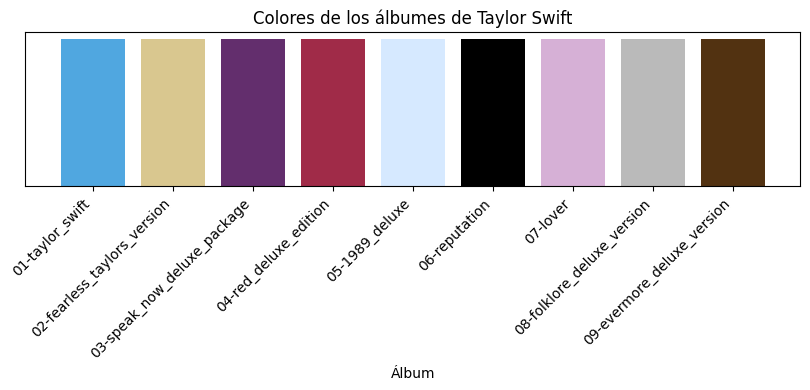

In [ ]:
# MOSTRAR LA PALETA DE COLORES
# CADA ALBUM SE REPRESENTA CON UN COLOR

plt.figure(figsize=(10, 2))
ax = plt.subplot()
for album, color in albums_colors.items():
    plt.bar(album, 1, color=color)
ax.set_yticks([])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Álbum')
plt.title('Colores de los álbumes de Taylor Swift')
plt.show()

In [ ]:
# nombres distintos de los álbumes como aparecen en el dataset
albumes_distintos = canciones_df['album_name'].unique()

print("NOMBRES DE LOS ALBUMES:")
print("")
for album in albumes_distintos:
    print("-",album)

NOMBRES DE LOS ALBUMES:

- reputation
- Red (Deluxe Edition)
- Taylor Swift
- Lover
- 1989 (Deluxe)
- Speak Now (Deluxe)
- Fearless (Taylor’s Version)
- folklore (deluxe version)
- evermore (deluxe version)


### 4. Analisis general de cada album

#### 4.1. Se asignan los colores a cada album

In [ ]:
# Paleta de colores
albums_colors = {
    "Taylor Swift": "#50a7e0",
    "Fearless (Taylor’s Version)": "#d9c78f",
    "Speak Now (Deluxe)": "#632e6d",
    "Red (Deluxe Edition)": "#a02b48",
    "1989 (Deluxe)": "#d6e9ff",
    "reputation": "#000000",
    "Lover": "#d6b0d6",
    "folklore (deluxe version)": "#bababa",
    "evermore (deluxe version)": "#523211"
}

#### 4.2. Histogramas separados de Caracteres por Album

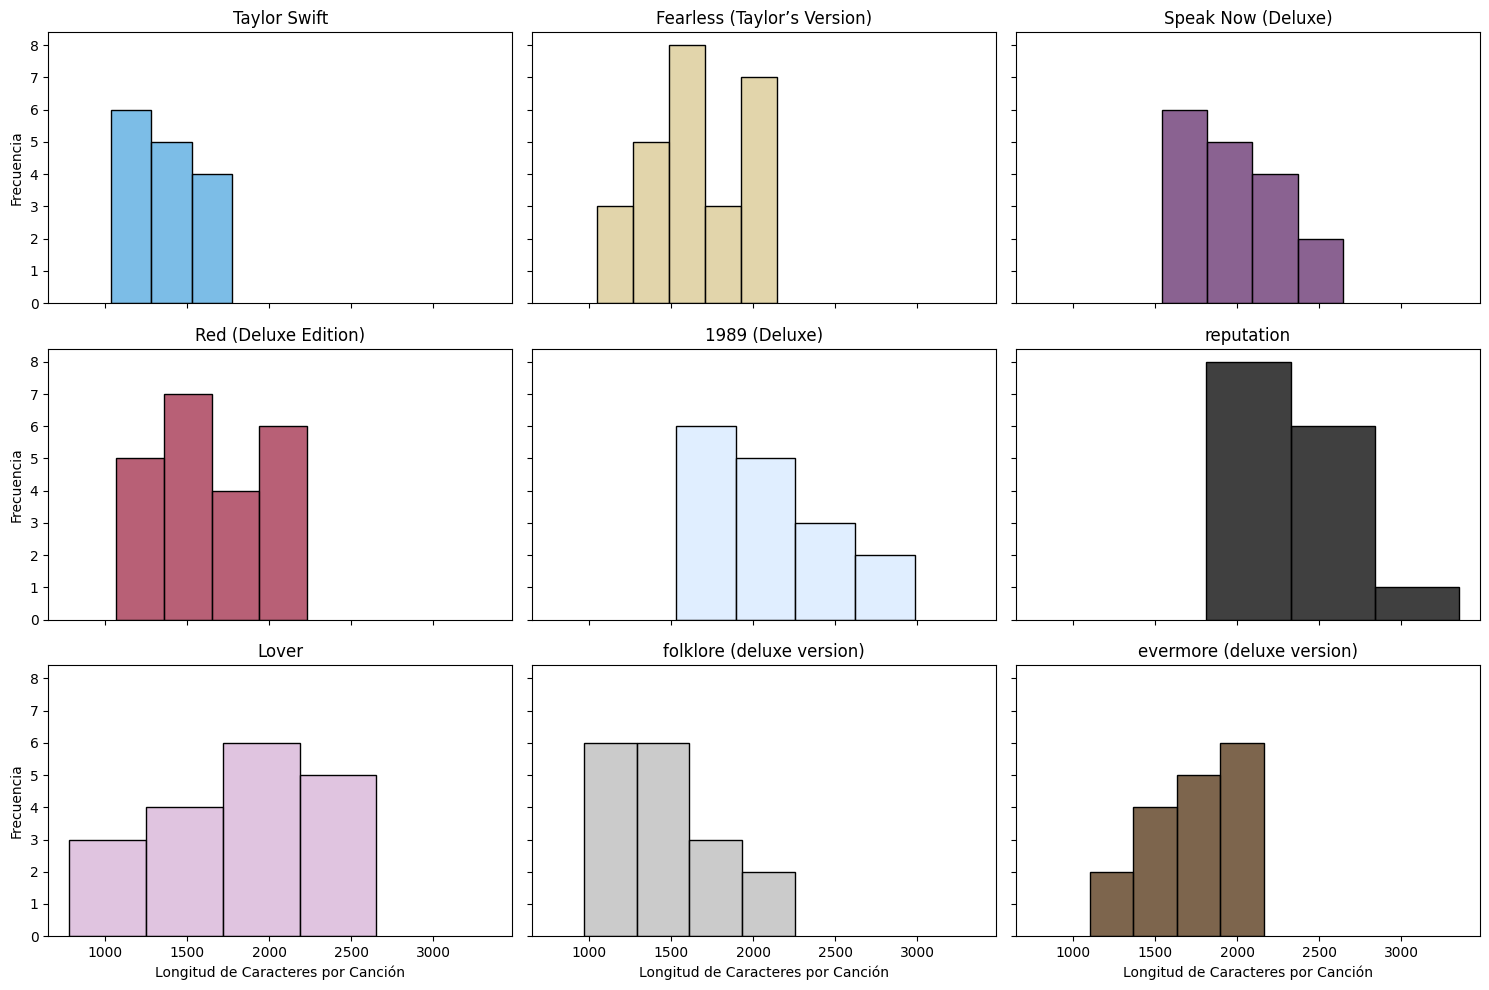

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, (album, color) in enumerate(albums_colors.items()):
    data = canciones_df[canciones_df['album_name'] == album]['lyric'].str.len()

    bins = int(np.sqrt(len(data)))

    ax = sns.histplot(data, bins=bins, color=color, ax=axes[i])
    ax.set_title(album)
    ax.set_xlabel('Longitud de Caracteres por Canción')
    ax.set_ylabel('Frecuencia')

    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()


In [ ]:
for i, (album, color) in enumerate(albums_colors.items()):
    data = canciones_df[canciones_df['album_name'] == album]['lyric'].str.len()
    print(sum(data))


20481
42504
33552
36307
33927
34651
32748
25024
29254


In [ ]:

sum_letras_por_album = {}
num_canciones_por_album = {}

for album, color in albums_colors.items():
    data = canciones_df[canciones_df['album_name'] == album]['lyric'].str.len()
    sum_letras_por_album[album] = sum(data)
    num_canciones_por_album[album] = len(data)

media_por_album = {}

for album in sum_letras_por_album:
    if num_canciones_por_album[album] != 0:
        media_por_album[album] = round(sum_letras_por_album[album] / num_canciones_por_album[album],2)
    else:
        media_por_album[album] = 0

media_por_album
df = pd.DataFrame(list(media_por_album.items()), columns=['Album', 'Media'])
df.T


,0,1,2,3,4,5,6,7,8
Album,Taylor Swift,Fearless (Taylor’s Version),Speak Now (Deluxe),Red (Deluxe Edition),1989 (Deluxe),reputation,Lover,folklore (deluxe version),evermore (deluxe version)
Media,1365.4,1634.77,1973.65,1650.32,2120.44,2310.07,1819.33,1472.0,1720.82


#### 4.3 Boxplot de longitud de caracteres por álbum

<ipython-input-13-e9dea45833b8>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=canciones_df, x='album_name', y=canciones_df['lyric'].str.len(), palette=albums_colors.values())
<ipython-input-13-e9dea45833b8>:4: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


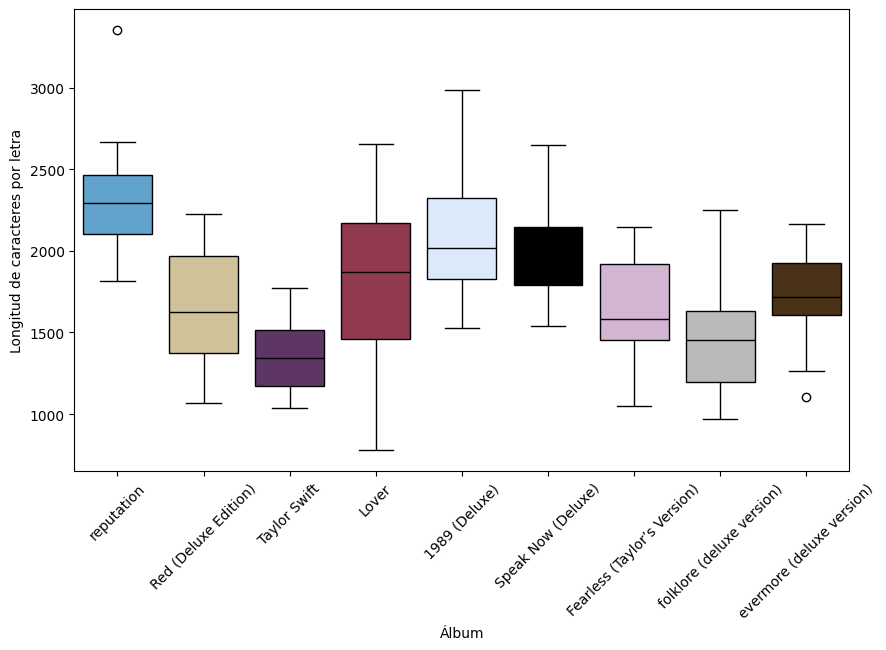

In [ ]:
plt.figure(figsize=(10, 6))

ax = sns.boxplot(data=canciones_df, x='album_name', y=canciones_df['lyric'].str.len(), palette=albums_colors.values())
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.xlabel('Álbum')
plt.ylabel('Longitud de caracteres por letra')

plt.show()


In [ ]:
evermore_df = canciones_df[canciones_df['album_name'] == 'evermore (deluxe version)']
min_evermore = evermore_df.loc[evermore_df['lyric'].str.len().idxmin()]

reputation_df = canciones_df[canciones_df['album_name'] == 'reputation']
max_reputation = reputation_df.loc[reputation_df['lyric'].str.len().idxmax()]

print("Canción con la letra más corta en 'evermore (deluxe version)':", min_evermore['track_title'])
print("Longitud de la letra:", len(min_evermore['lyric']))
print()
print("Canción con la letra más larga en 'reputation':", max_reputation['track_title'])
print("Longitud de la letra:", len(max_reputation['lyric']))


Canción con la letra más corta en 'evermore (deluxe version)': ​closure
Longitud de la letra: 1103

Canción con la letra más larga en 'reputation': End Game
Longitud de la letra: 3352


In [ ]:

num_canciones_por_album = {}
for album, color in albums_colors.items():
    data = canciones_df[canciones_df['album_name'] == album]['lyric'].str.len()
    num_canciones_por_album[album] = len(data)

min_por_album = {}
max_por_album = {}
for album in num_canciones_por_album.keys():
    data = canciones_df[canciones_df['album_name'] == album]['lyric'].str.len()
    min_por_album[album] = min(data)
    max_por_album[album] = max(data)

min_max_por_album = {'Album': list(min_por_album.keys()), 'Mínimo': list(min_por_album.values()), 'Máximo': list(max_por_album.values())}
df_min_max = pd.DataFrame(min_max_por_album)

df_transpuesto = df_min_max.set_index('Album').T

df_transpuesto


Album,Taylor Swift,Fearless (Taylor’s Version),Speak Now (Deluxe),Red (Deluxe Edition),1989 (Deluxe),reputation,Lover,folklore (deluxe version),evermore (deluxe version)
Mínimo,1035,1047,1539,1068,1527,1813,780,970,1103
Máximo,1771,2143,2646,2227,2988,3352,2652,2252,2162


#### 4.4. Analisis del largo del título

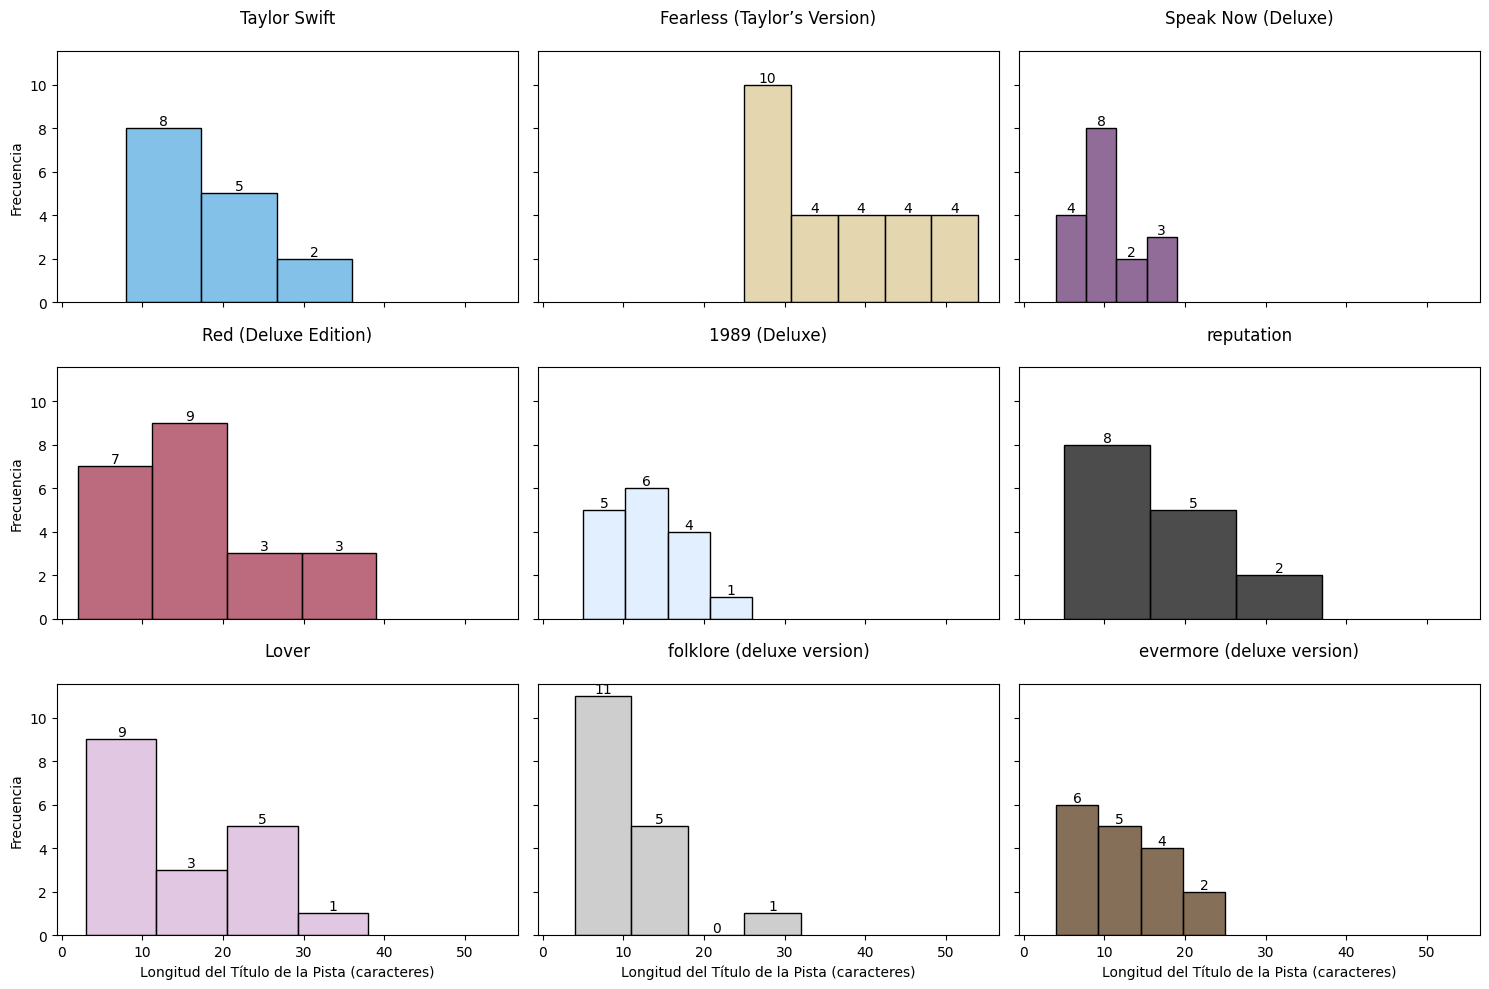

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, (album, color) in enumerate(albums_colors.items()):
    data = canciones_df[canciones_df['album_name'] == album]['track_title'].str.len()

    bins = int(np.sqrt(len(data)))

    if len(data) > 0:
        bin_range = np.linspace(data.min(), data.max(), bins + 1)
        ax = sns.histplot(data, bins=bin_range, color=color, ax=axes[i], alpha=0.7)
    else:
        ax = sns.histplot([], bins=bins, color=color, ax=axes[i], alpha=0.7)

    ax.set_title(album, pad=20)
    ax.set_xlabel('Longitud del Título de la Pista (caracteres)')
    ax.set_ylabel('Frecuencia')

    for bar in ax.patches:
        ax.annotate(f'{bar.get_height():.0f}',
                    (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha='center', va='bottom', color='black')

plt.tight_layout()
if len(albums_colors) < 9:
    for idx in range(len(albums_colors), 9):
        plt.delaxes(axes[idx])

plt.show()

#### 4.5. Canciones por album

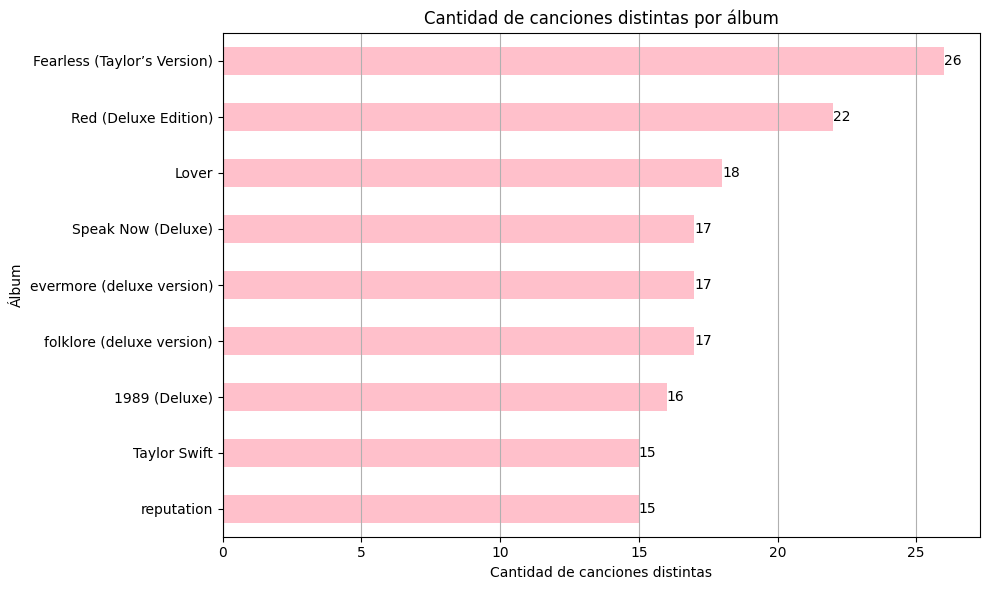

In [ ]:
plt.figure(figsize=(10, 6))
canciones_por_album = canciones_df.groupby('album_name')['track_title'].nunique().sort_values(ascending=False)

bar_plot = canciones_por_album.plot(kind='barh', color='pink')
plt.title('Cantidad de canciones distintas por álbum')
plt.xlabel('Cantidad de canciones distintas')
plt.ylabel('Álbum')
plt.grid(axis='x')
plt.tight_layout()

plt.gca().invert_yaxis()
for bar in bar_plot.patches:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'{bar.get_width():.0f}',
             va='center', ha='left', fontsize=10, color='black')
plt.show()

### 5. Tokenizacion

##### 5.1. Tokenización de las canciones

In [ ]:
# Se procesa el df_canciones, dividiendo las letras de las canciones en palabras (tokens)
# y despues se limplian estos tokens eliminando caracteres no alfabéticos y normalizando las palabras a minúsculas
canciones_df['token'] = canciones_df['lyric'].apply(word_tokenize)
canciones_df['token'] = [[token.lower() for token in tokens if token.isalpha()] for tokens in canciones_df['token']]
print(canciones_df['token'])

0      [knew, he, was, a, killer, first, time, that, ...
1      [it, feels, like, a, perfect, nightto, dress, ...
2      [why, would, you, wan, na, break, a, perfectly...
3      [i, do, know, what, i, want, so, do, ask, i, s...
4      [i, blew, things, out, of, proportion, now, yo...
                             ...                        
158    [friends, break, up, friends, get, marriedstra...
159    [is, it, romantic, how, all, my, elegies, eulo...
160    [rebekah, rode, up, on, the, afternoon, train,...
161    [i, sit, and, watch, you, reading, with, your,...
162    [if, i, wanted, to, know, who, you, were, hang...
Name: token, Length: 163, dtype: object


##### 5.2: eliminación de stopwords

In [ ]:
nltk.download('stopwords')
stoplist = set(stopwords.words("english"))
stoplist.update(['like', 'na', 'oh'])
canciones_df['token'] = [[token for token in tokens if token.lower() not in stoplist and token.isalpha()] for tokens in canciones_df['token']]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


### 6. Análisis de palabras

##### 6.1. Top 5 palabras mas usadas

In [ ]:
total_word_freq = Counter()
album_word_freq = {album: Counter() for album in canciones_df['album_name'].unique()}
song_word_freq = {}
for index, row in canciones_df.iterrows():
    album = row['album_name']
    lyric_tokens = row['token']
    song_word_freq[index] = Counter(lyric_tokens)
    album_word_freq[album].update(lyric_tokens)
    total_word_freq.update(lyric_tokens)


album_top_words = {album: freq.most_common(5) for album, freq in album_word_freq.items()}
song_top_words = {index: freq.most_common(5) for index, freq in song_word_freq.items()}
total_top_words = total_word_freq.most_common(10)


print("Las 5 palabras más usadas por álbum y sus frecuencias:")
for album, top_words in album_top_words.items():
    print(album)
    for word, freq in top_words:
        print(f"{word}: {freq}")
    print()

print("\nLas 5 palabras más usadas en cada canción y sus frecuencias:")
for index, top_words in song_top_words.items():
    print(f"Canción {index}:")
    for word, freq in top_words:
        print(f"{word}: {freq}")
    print()

print("\nLas 10 palabras más usadas en total y sus frecuencias:")
for word, freq in total_top_words:
    print(f"{word}: {freq}")


Las 5 palabras más usadas por álbum y sus frecuencias:
reputation
made: 52
want: 50
call: 39
wan: 37
first: 31

Red (Deluxe Edition)
know: 74
never: 72
time: 54
red: 46
back: 36

Taylor Swift
wan: 26
never: 26
back: 25
know: 25
think: 24

Lover
never: 43
see: 42
wan: 40
want: 40
one: 36

1989 (Deluxe)
love: 78
eh: 72
shake: 67
yet: 64
got: 49

Speak Now (Deluxe)
back: 60
ever: 33
know: 32
see: 30
never: 29

Fearless (Taylor’s Version)
know: 73
feel: 44
come: 40
said: 39
never: 37

folklore (deluxe version)
never: 45
know: 37
would: 26
knew: 18
think: 18

evermore (deluxe version)
know: 49
could: 33
think: 27
left: 21
got: 20


Las 5 palabras más usadas en cada canción y sus frecuencias:
Canción 0:
games: 12
beginlet: 8
see: 7
gon: 7
middle: 7

Canción 1:
feels: 8
one: 8
know: 7
alright: 7
keep: 6

Canción 2:
would: 19
wan: 17
break: 9
perfectly: 7
good: 7

Canción 3:
girl: 6
trying: 4
alone: 4
knowi: 3
strong: 3

Canción 4:
wan: 13
need: 7
lose: 7
ooh: 6
love: 4

Canción 5:
remember: 9

##### 6.2. ¿En que albumes aparecen las 10 palabras mas frecuentes?

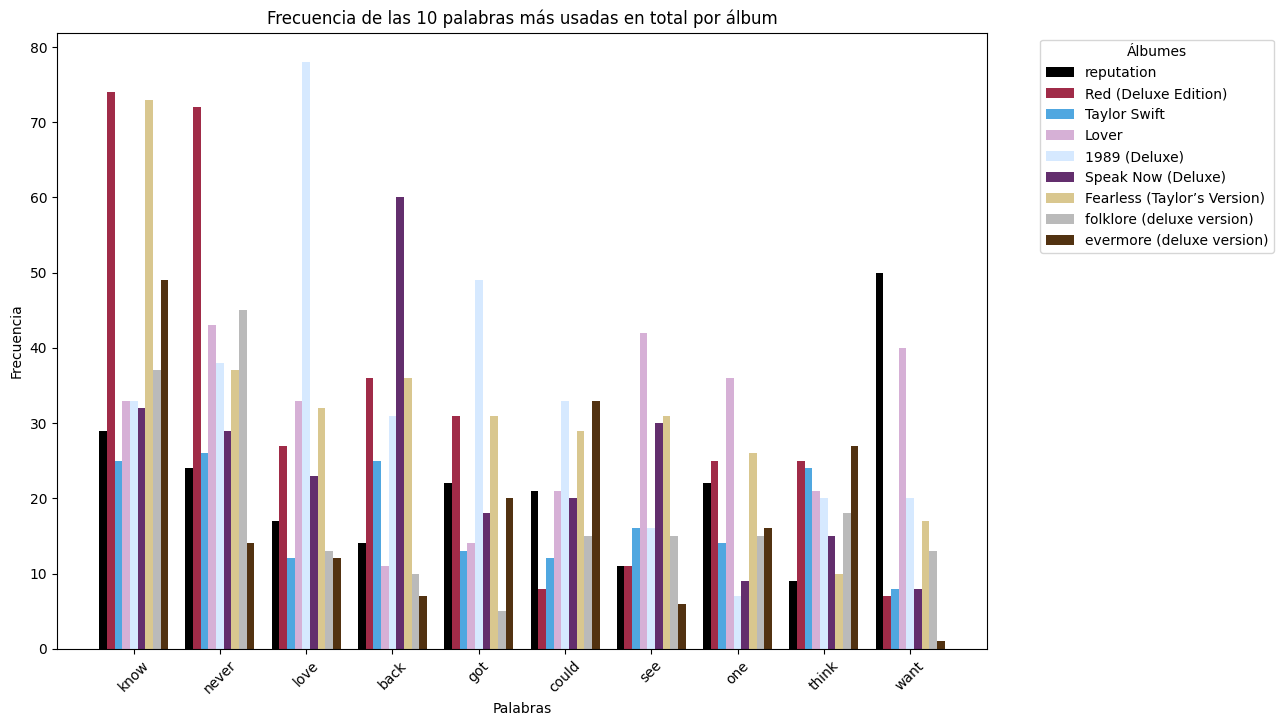

In [ ]:
# Veamos en qué álbumes son más frecuentes el top 10 de palabras más repetidas por Taylor

top_words = [word for word, _ in total_top_words]
fig, ax = plt.subplots(figsize=(12, 8))
width = 0.8 / len(album_word_freq)
indices = np.arange(len(top_words))

for i, (album, counter) in enumerate(album_word_freq.items()):
    freqs = [counter[word] for word in top_words]
    ax.bar(indices + i * width, freqs, width=width, color=albums_colors[album], label=album)

ax.set_xticks(indices + width * len(album_word_freq) / 2 - width / 2)
ax.set_xticklabels(top_words, rotation=45)
ax.set_title('Frecuencia de las 10 palabras más usadas en total por álbum')
ax.set_xlabel('Palabras')
ax.set_ylabel('Frecuencia')
ax.legend(title='Álbumes', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

##### 6.3. ¿Qué tan correlacionado está la cantidad de canciones por álbum con la aparición de las 10 palabras mas repetidas en todos los álbunes?

In [ ]:
#### Se calcula la correlacion entre la cantidad total de palabras y la frecuencia de apariciones del top10.

total_words_per_album = {album: sum(freq.values()) for album, freq in album_word_freq.items()}
top_words_sum_per_album = {
    album: sum(freq[word] for word in top_words if word in freq)
    for album, freq in album_word_freq.items()
}

total_words_list = [total_words_per_album[album] for album in album_word_freq]
top_words_freq_list = [top_words_sum_per_album[album] for album in album_word_freq]
correlation = np.corrcoef(total_words_list, top_words_freq_list)[0, 1]

print(f"La correlación entre la cantidad total de palabras y la frecuencia de las top 10 palabras por álbum es: {correlation}")


La correlación entre la cantidad total de palabras y la frecuencia de las top 10 palabras por álbum es: 0.8564192066681249


La correlación fue del 85% por lo que es necesario normalizar la cantidad de apariciones de cada palabra del top 10 por el total de palabras del album
Este enfoque  permite comparar álbumes de diferentes tamaños más justamente, ya que mide la prevalencia de palabras específicas en relación con el tamaño del contenido de cada álbum.

Por lo tanto, se vuelve a hacer el histograma de top 10 pero con las frecuencias normalizadas

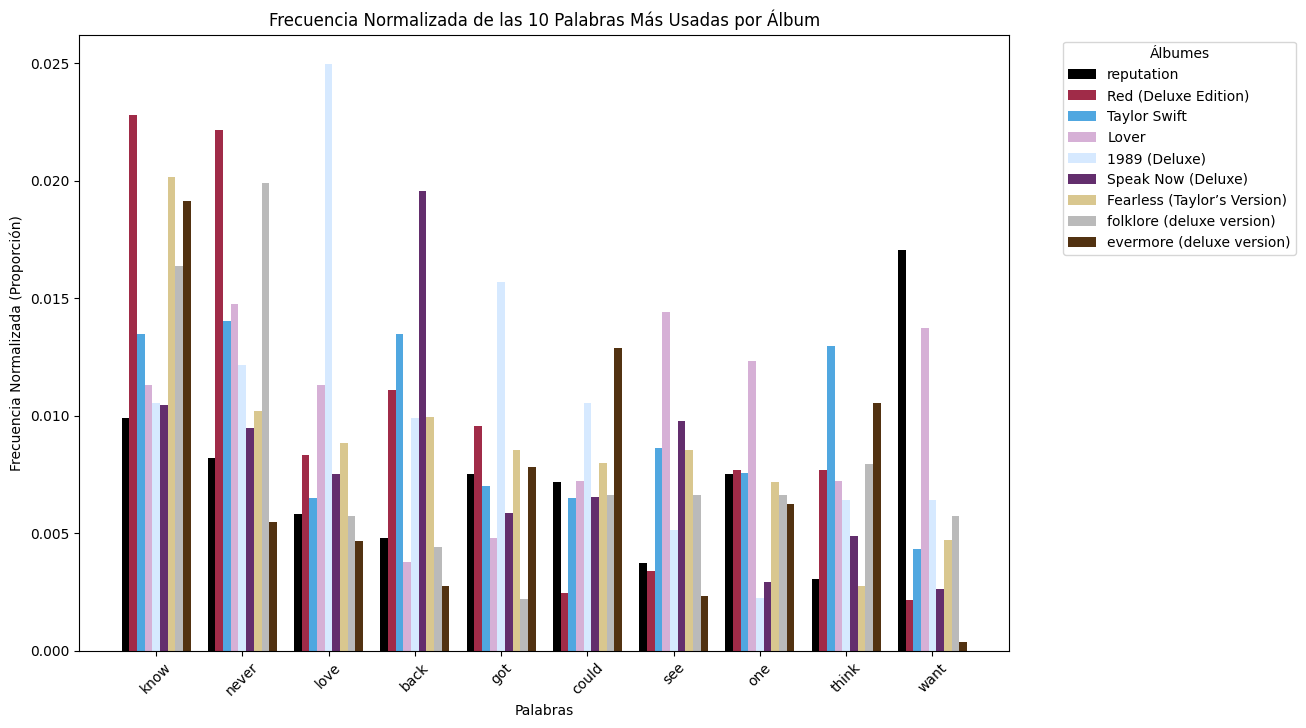

In [ ]:
normalized_top_words_per_album = {
    album: {word: (freq[word] / total_words_per_album[album]) for word in top_words if word in freq}
    for album, freq in album_word_freq.items()
}

normalized_sums = {
    album: sum(normalized_freq.values())
    for album, normalized_freq in normalized_top_words_per_album.items()
}

normalized_freq_list = [normalized_sums[album] for album in album_word_freq]

fig, ax = plt.subplots(figsize=(12, 8))
width = 0.8 / len(album_word_freq)

indices = np.arange(len(top_words))

for i, (album, normalized_freq) in enumerate(normalized_top_words_per_album.items()):
    freqs = [normalized_freq.get(word, 0) for word in top_words]  # Usar get para manejar palabras que podrían no estar en algunos álbumes
    ax.bar(indices + i * width, freqs, width=width, color=albums_colors[album], label=album)

ax.set_xticks(indices + width * len(album_word_freq) / 2 - width / 2)
ax.set_xticklabels(top_words, rotation=45)
ax.set_title('Frecuencia Normalizada de las 10 Palabras Más Usadas por Álbum')
ax.set_xlabel('Palabras')
ax.set_ylabel('Frecuencia Normalizada (Proporción)')
ax.legend(title='Álbumes', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

##### 6.4. Matriz con las frecuencias del token por album

In [ ]:
# Se arma una matriz con las frecuencias de cada token (top10) en cada album
frecuencias_por_album = {}
for index, row in canciones_df.iterrows():
    album = row['album_name']
    tokens = row['token']
    if album not in frecuencias_por_album:
        frecuencias_por_album[album] = {}
    for token in tokens:
        if token in frecuencias_por_album[album]:
            frecuencias_por_album[album][token] += 1
        else:
            frecuencias_por_album[album][token] = 1

# 10 palabras más frecuentes en el conjunto de tokens
palabras_mas_frecuentes = canciones_df['token'].explode().value_counts().head(10).index.tolist()

# Matriz para almacenar las frecuencias de estas palabras en cada álbum
matriz_frecuencias = pd.DataFrame(index=palabras_mas_frecuentes, columns=frecuencias_por_album.keys())

for album, frecuencias in frecuencias_por_album.items():
    for palabra in palabras_mas_frecuentes:
        if palabra in frecuencias:
            matriz_frecuencias.at[palabra, album] = frecuencias[palabra]
        else:
            matriz_frecuencias.at[palabra, album] = 0


print(matriz_frecuencias)

      reputation Red (Deluxe Edition) Taylor Swift Lover 1989 (Deluxe)  \
know          29                   74           25    33            33   
never         24                   72           26    43            38   
love          17                   27           12    33            78   
back          14                   36           25    11            31   
got           22                   31           13    14            49   
could         21                    8           12    21            33   
see           11                   11           16    42            16   
one           22                   25           14    36             7   
think          9                   25           24    21            20   
want          50                    7            8    40            20   

      Speak Now (Deluxe) Fearless (Taylor’s Version)  \
know                  32                          73   
never                 29                          37   
love             

##### 6.5. Heatmap que muestra la frecuencia de cada palabra por album

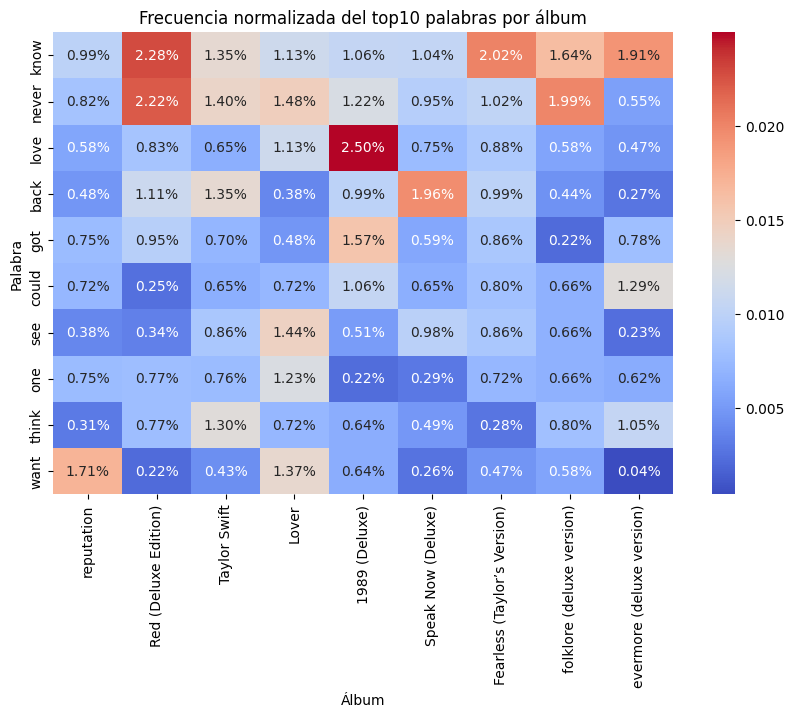

In [ ]:
albums = list(normalized_top_words_per_album.keys())
words = top_words

# Se crea la matriz de frecuencias normalizadas
data = []
for word in words:
    row = []
    for album in albums:
        row.append(normalized_top_words_per_album[album].get(word, 0))
    data.append(row)
matriz_frecuencias = pd.DataFrame(data, index=words, columns=albums)

plt.figure(figsize=(10, 6))
sns.heatmap(matriz_frecuencias, cmap="coolwarm", annot=True, fmt=".2%", annot_kws={"size": 10})  # Cambiar el formato a porcentaje con 2 decimales
plt.title('Frecuencia normalizada del top10 palabras por álbum')
plt.xlabel('Álbum')
plt.ylabel('Palabra')
plt.show()

### 7. Análisis de sentimiento

##### 7.1. Analisis de sentimiento por álbum

In [ ]:
def sentiment_analysis(text):
    return TextBlob(text).sentiment

canciones_df['Sentiment'] = canciones_df['lyric'].apply(lambda x: sentiment_analysis(x))

canciones_df['Polarity'] = canciones_df['Sentiment'].apply(lambda x: x.polarity)
canciones_df['Subjectivity'] = canciones_df['Sentiment'].apply(lambda x: x.subjectivity)

average_sentiments = canciones_df.groupby('album_name').agg({
    'Polarity': 'mean',
    'Subjectivity': 'mean'
}).reset_index()

print(average_sentiments)


                    album_name  Polarity  Subjectivity
0                1989 (Deluxe)  0.031426      0.528284
1  Fearless (Taylor’s Version)  0.113118      0.462570
2                        Lover  0.059864      0.575313
3         Red (Deluxe Edition)  0.127486      0.478021
4           Speak Now (Deluxe)  0.133647      0.470712
5                 Taylor Swift  0.127330      0.530146
6    evermore (deluxe version)  0.126051      0.457328
7    folklore (deluxe version)  0.046440      0.559335
8                   reputation  0.090829      0.493250


##### 7.2. Graficos polaridad y subjetividad por álbum

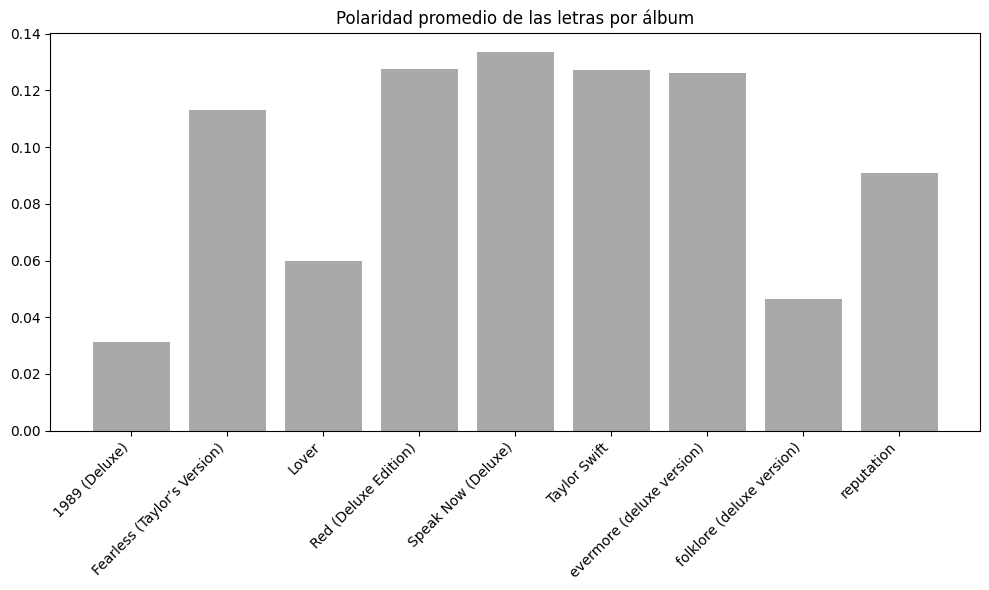

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(average_sentiments['album_name'], average_sentiments['Polarity'], color='darkgrey')
plt.title('Polaridad promedio de las letras por álbum')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

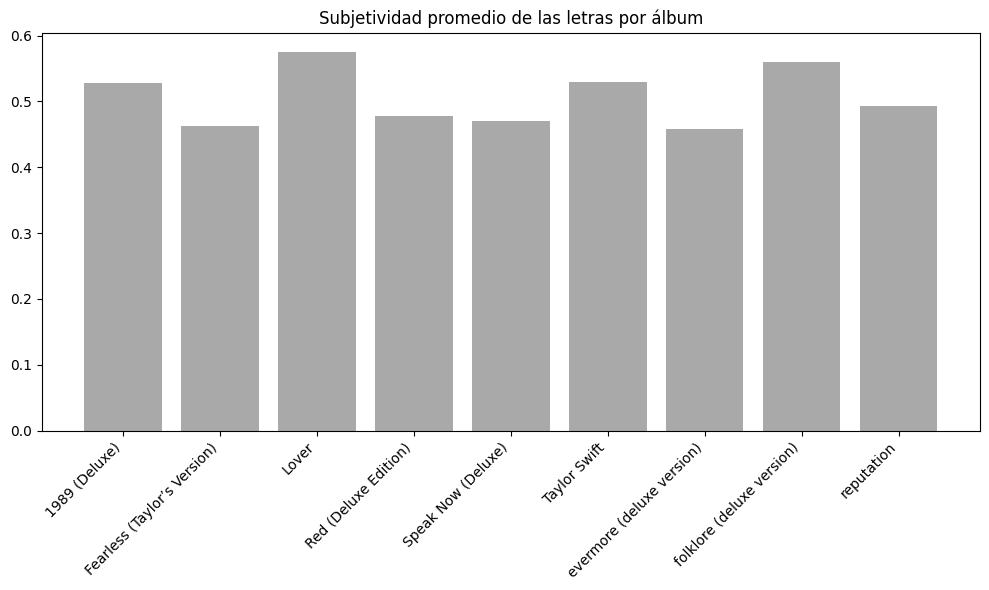

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(average_sentiments['album_name'], average_sentiments['Subjectivity'], color='darkgrey')
plt.title('Subjetividad promedio de las letras por álbum')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 7.3. Top 10 canciones con sentimiento más positivo

In [ ]:
def sentiment_analysis(text):
    return TextBlob(text).sentiment.polarity

merged_df['Sentiment'] = merged_df['lyric'].apply(sentiment_analysis)

average_sentiments_by_song = merged_df.groupby('track_title')['Sentiment'].mean().reset_index()

In [ ]:
### 10 canciones con sentimiento mas positivo
top_positive_songs = average_sentiments_by_song.sort_values(by='Sentiment', ascending=False).head(10)
print("Top 10 Canciones con Sentimiento Más Positivo:")
print(top_positive_songs[['track_title', 'Sentiment']])


Top 10 Canciones con Sentimiento Más Positivo:
                                           track_title  Sentiment
119  We Were Happy (Taylor’s Version) [From the Vault]   0.350152
2                               A Perfectly Good Heart   0.341667
120                                Welcome to New York   0.334728
81                                Sad Beautiful Tragic   0.206742
109             The Way I Loved You (Taylor’s Version)   0.199571
111                                          This Love   0.197151
160                   ​the last great american dynasty   0.191727
34                         Fearless (Taylor’s Version)   0.191112
147                                         ​happiness   0.182995
92                                      Stay Stay Stay   0.179217


In [ ]:
### 10 canciones con sentimiento mas negativo
top_negative_songs = average_sentiments_by_song.sort_values(by='Sentiment', ascending=True).head(10)
print("\nTop 10 Canciones con Sentimiento Más Negativo:")
print(top_negative_songs[['track_title', 'Sentiment']])


Top 10 Canciones con Sentimiento Más Negativo:
                        track_title  Sentiment
8                         Bad Blood  -0.184820
153                      ​mad woman  -0.154722
67                             Mean  -0.136501
78                  Picture To Burn  -0.109625
137               this is me trying  -0.100335
48          I Knew You Were Trouble  -0.073935
98   Tell Me Why (Taylor’s Version)  -0.073689
82                     Shake It Off  -0.071286
12       Breathe (Taylor’s Version)  -0.071016
139                          ​betty  -0.069510


##### 7.4. ¿Hay correlacion entre el album y el nivel de sentimiento de sus canciones?

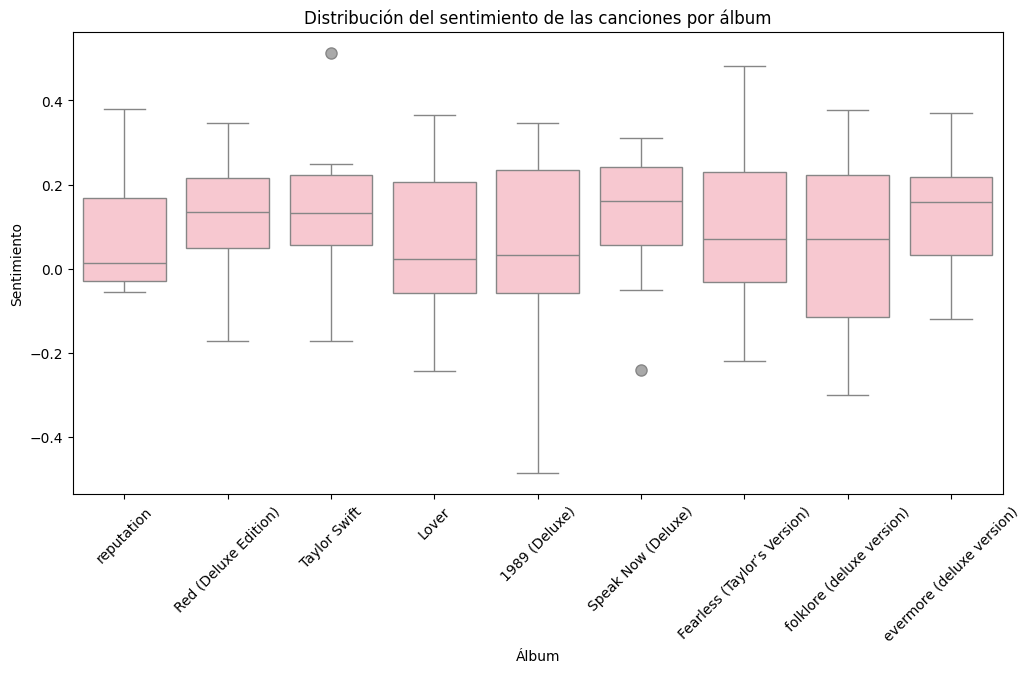

In [ ]:
plt.figure(figsize=(12, 6))
caja_color = "pink"
punto_color = "darkgray"
sns.boxplot(data=canciones_df, x='album_name', y='Polarity', color=caja_color, flierprops=dict(marker='o', markerfacecolor=punto_color, markersize=8))

plt.title('Distribución del sentimiento de las canciones por álbum')
plt.xlabel('Álbum')
plt.ylabel('Sentimiento')
plt.xticks(rotation=45)
plt.show()

Las cajas son muy similares en altura, por lo que los niveles de sentimiento son consistentes entre los álbumes.

Los puntos fuera de los bigotes indican que, en algunos albumes, hay alta variabilidad en los niveles de sentimiento dentro de un álbum, o puede indicar la presencia de valores atípicos.